✅ Paths configured successfully!
Sensors folder: E:\trio_grad\2020-DiversityOne-Trento\Sensors\App-usage
Diachronic folder: E:\trio_grad\2020-DiversityOne-Trento\Diachronic-Interactions
✅ Loaded 177487 samples for correlation analysis


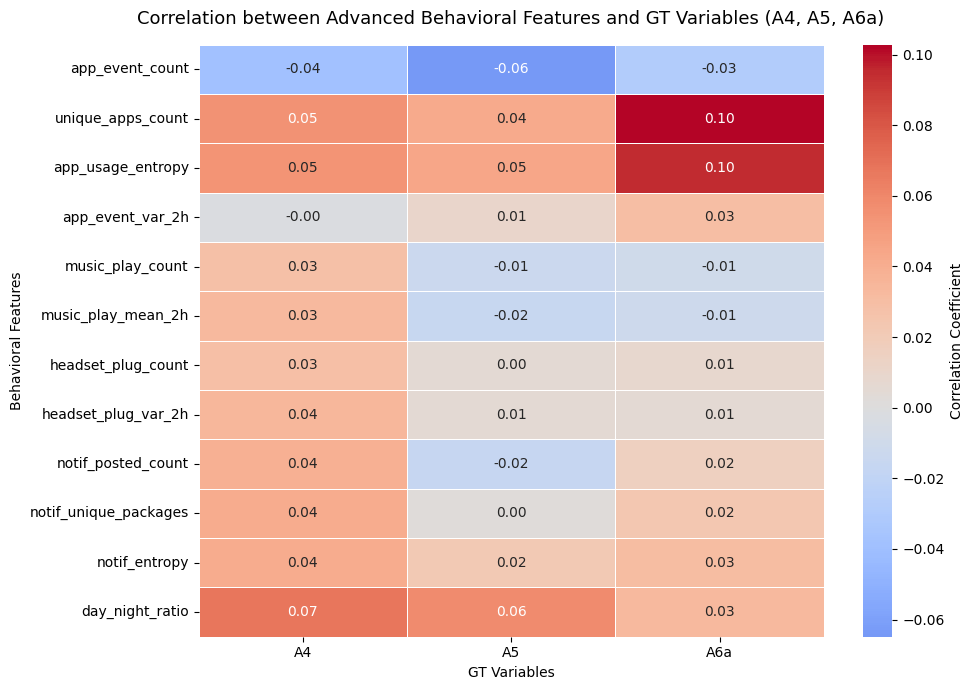

In [1]:
# =======================================
# correlation_analysis.py (v2)
# =======================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from config import OUTPUT_DIR

data_path = f"{OUTPUT_DIR}/final_dataset_halfhour_v2.csv"
df = pd.read_csv(data_path)
print(f"✅ Loaded {df.shape[0]} samples for correlation analysis")

feature_cols = [
    "app_event_count", "unique_apps_count", "app_usage_entropy",
    "app_event_var_2h", "music_play_count", "music_play_mean_2h",
    "headset_plug_count", "headset_plug_var_2h",
    "notif_posted_count", "notif_unique_packages", "notif_entropy",
    "day_night_ratio"
]
target_cols = ["A4", "A5", "A6a"]

corr_df = df[feature_cols + target_cols].corr()
corr_target = corr_df.loc[feature_cols, target_cols]

plt.figure(figsize=(10, 7))
sns.heatmap(corr_target, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title("Correlation between Advanced Behavioral Features and GT Variables (A4, A5, A6a)", fontsize=13, pad=15)
plt.xlabel("GT Variables")
plt.ylabel("Behavioral Features")
plt.tight_layout()
plt.show()
